# EDA — PubMed Summarization
## Base para fine-tuning do BioBART para sumarização de abstracts biomédicos

Dataset: [`ccdv/pubmed-summarization`](https://huggingface.co/datasets/ccdv/pubmed-summarization)  
Campos: `article` (texto completo) · `abstract` (resumo de referência)  
Tokenizer alvo: `GanjinZero/biobart-v2-base`

---
## 0 · Requisitos
Execute a célula abaixo apenas uma vez para instalar as dependências.

In [ ]:
%pip install -q datasets transformers pandas numpy matplotlib seaborn nltk tqdm

---
## 1 · Setup
Importações, configuração de estilo e carregamento do dataset.

In [7]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import re

import nltk
from nltk.corpus import stopwords

from datasets import load_dataset
from transformers import AutoTokenizer

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

# Estilo global
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 4)

SEED = 42
SAMPLE_SIZE = 5_000   # subconjunto para EDA rapida
BIOBART_CKPT = 'GanjinZero/biobart-v2-base'

print('Imports OK')

Imports OK


In [8]:
print('Carregando dataset (pode demorar alguns minutos na primeira vez)...')
raw = load_dataset('ccdv/pubmed-summarization')
print(raw)

Carregando dataset (pode demorar alguns minutos na primeira vez)...
DatasetDict({
    train: Dataset({
        features: ['article', 'abstract'],
        num_rows: 119924
    })
    validation: Dataset({
        features: ['article', 'abstract'],
        num_rows: 6633
    })
    test: Dataset({
        features: ['article', 'abstract'],
        num_rows: 6658
    })
})


In [9]:
# Subconjunto de treino para a EDA
train_sample = raw['train'].shuffle(seed=SEED).select(range(SAMPLE_SIZE))
df = pd.DataFrame({'article': train_sample['article'], 'abstract': train_sample['abstract']})

print(f'Amostra de trabalho: {len(df):,} exemplos')
df.head(2)

Amostra de trabalho: 5,000 exemplos


,article,abstract
0,atrial fibrillation ( af ) is the most common ...,atrial fibrillation \n ( af ...
1,breast cancer is the most frequently diagnosed...,breast cancer is the major cause of cancer mor...


---
## 2 · Visão Geral do Dataset

### 2.1 Tamanho de cada split

Tamanho dos splits (dataset completo):
  train       :  119,924 exemplos
  validation  :    6,633 exemplos
  test        :    6,658 exemplos


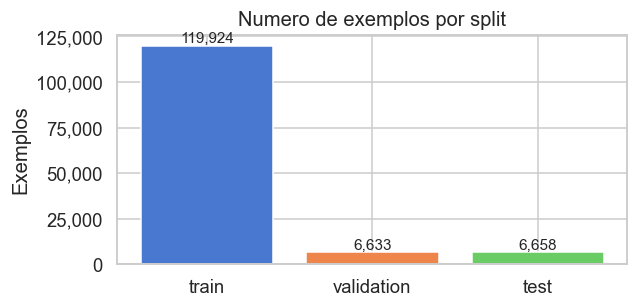

In [10]:
split_sizes = {split: len(raw[split]) for split in raw}
print('Tamanho dos splits (dataset completo):')
for split, n in split_sizes.items():
    print(f'  {split:12s}: {n:>8,} exemplos')

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(split_sizes.keys(), split_sizes.values(), color=sns.color_palette('muted')[:3], edgecolor='white')
ax.set_title('Numero de exemplos por split')
ax.set_ylabel('Exemplos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in ax.patches:
    ax.annotate(f'{int(bar.get_height()):,}',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

### 2.2 Exemplos completos

In [11]:
def show_example(idx, df):
    sep = '-' * 80
    print(sep)
    print('EXEMPLO #' + str(idx))
    print(sep)
    art_words = len(df.loc[idx, 'article'].split())
    abs_words = len(df.loc[idx, 'abstract'].split())
    print('ARTICLE (' + str(art_words) + ' palavras):\n')
    print(df.loc[idx, 'article'][:800] + ' ...')
    print()
    print('ABSTRACT (' + str(abs_words) + ' palavras):\n')
    print(df.loc[idx, 'abstract'])
    print()

for i in [0, 1, 2]:
    show_example(i, df)

--------------------------------------------------------------------------------
EXEMPLO #0
--------------------------------------------------------------------------------
ARTICLE (2041 palavras):

atrial fibrillation ( af ) is the most common sustained arrhythmia in western countries , with an estimated 30 million patients affected by 2050 across united states and europe alone . 
 atrial fibrillation has a significant impact on morbidity mainly related to symptoms , heart failure , and thromboembolic events and is the most frequent arrhythmic cause of hospital admission in the usa     [ 13 ] . 
 in addition , af is associated with excess mortality independently of thromboembolic complications     . to date , the most effective treatment for af is radiofrequency catheter ablation , and pulmonary vein antrum isolation ( pvai ) is the mainstay of such an approach     . 
 the major drawback of catheter ablation of af consists in its potential risk of periprocedural complications     , w 

### 2.3 Valores nulos e textos vazios

In [12]:
print('=== Valores nulos ===')
print(df.isnull().sum())

df['article_empty'] = df['article'].str.strip().eq('')
df['abstract_empty'] = df['abstract'].str.strip().eq('')

print('\nArtigos vazios  : ' + str(df['article_empty'].sum()))
print('Abstracts vazios: ' + str(df['abstract_empty'].sum()))

# Limpar eventuais vazios
before = len(df)
df = df[~df['article_empty'] & ~df['abstract_empty']].reset_index(drop=True)
print('\nExemplos apos limpeza: ' + str(len(df)) + ' (removidos ' + str(before - len(df)) + ')')

=== Valores nulos ===
article     0
abstract    0
dtype: int64

Artigos vazios  : 132
Abstracts vazios: 0

Exemplos apos limpeza: 4868 (removidos 132)


---
## 3 · Análise de Comprimento

Analisamos o comprimento em **palavras** (rápido, independente de tokenizer) e em  
**tokens BioBART** (essencial para definir `max_input_length` e `max_target_length`).

### 3.1 Comprimento em palavras

In [13]:
df['art_words']  = df['article'].str.split().str.len()
df['abs_words']  = df['abstract'].str.split().str.len()

def word_stats(series, label):
    print('\n--- ' + label + ' ---')
    print(f'  Media   : {series.mean():>8.1f}')
    print(f'  Mediana : {series.median():>8.1f}')
    print(f'  P90     : {series.quantile(0.90):>8.1f}')
    print(f'  P95     : {series.quantile(0.95):>8.1f}')
    print(f'  P99     : {series.quantile(0.99):>8.1f}')
    print(f'  Maximo  : {series.max():>8.0f}')

word_stats(df['art_words'],  'Article  -- palavras')
word_stats(df['abs_words'],  'Abstract -- palavras')


--- Article  -- palavras ---
  Media   :   3132.5
  Mediana :   2592.0
  P90     :   5826.6
  P95     :   7186.4
  P99     :  11175.2
  Maximo  :    47413

--- Abstract -- palavras ---
  Media   :    202.5
  Mediana :    210.0
  P90     :    302.0
  P95     :    324.0
  P99     :    356.0
  Maximo  :      381


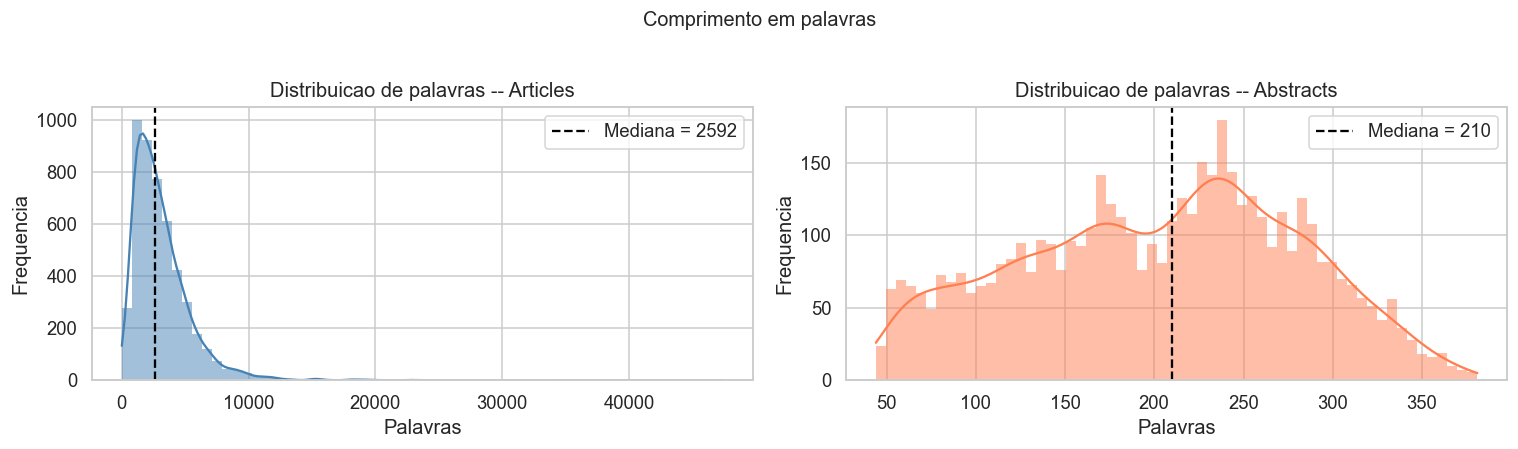

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col, color, label in zip(
    axes,
    ['art_words', 'abs_words'],
    ['steelblue', 'coral'],
    ['Articles', 'Abstracts']
):
    sns.histplot(df[col], bins=60, ax=ax, color=color, kde=True, edgecolor='none')
    ax.axvline(df[col].median(), color='black', ls='--', lw=1.5,
               label='Mediana = ' + str(int(df[col].median())))
    ax.set_title('Distribuicao de palavras -- ' + label)
    ax.set_xlabel('Palavras')
    ax.set_ylabel('Frequencia')
    ax.legend()

plt.suptitle('Comprimento em palavras', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

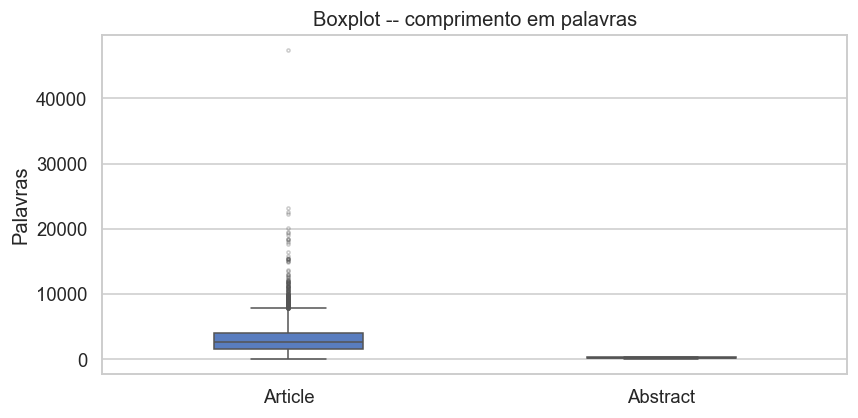

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
bp_data = pd.melt(
    df[['art_words', 'abs_words']],
    var_name='Tipo',
    value_name='Palavras'
)
bp_data['Tipo'] = bp_data['Tipo'].map({'art_words': 'Article', 'abs_words': 'Abstract'})

sns.boxplot(data=bp_data, x='Tipo', y='Palavras', palette='muted', width=0.4, ax=ax,
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax.set_title('Boxplot -- comprimento em palavras')
ax.set_xlabel('')
ax.set_ylabel('Palavras')
plt.tight_layout()
plt.show()

### 3.2 Comprimento em tokens BioBART

> Esta etapa faz download do tokenizer (~500 MB na primeira execução).  
> A tokenização de 5 000 pares pode levar 2–4 min dependendo da CPU.

In [16]:
print('Carregando tokenizer: ' + BIOBART_CKPT + ' ...')
tokenizer = AutoTokenizer.from_pretrained(BIOBART_CKPT)
print('Vocabulario: ' + str(tokenizer.vocab_size) + ' tokens | Model max_length: ' + str(tokenizer.model_max_length))

Carregando tokenizer: GanjinZero/biobart-v2-base ...


config.json:   0%|          | 0.00/1.72k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.13k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.59M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/892k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

Vocabulario: 85401 tokens | Model max_length: 1000000000000000019884624838656


In [17]:
from tqdm.auto import tqdm
tqdm.pandas(desc='Tokenizando')

def count_tokens(text):
    return len(tokenizer(text, add_special_tokens=True)['input_ids'])

print('Tokenizando articles...')
df['art_tokens'] = df['article'].progress_apply(count_tokens)

print('Tokenizando abstracts...')
df['abs_tokens'] = df['abstract'].progress_apply(count_tokens)

print('Concluido!')
df[['art_tokens', 'abs_tokens']].describe().round(1)

Tokenizando articles...


Tokenizando:   0%|          | 0/4868 [00:00<?, ?it/s]

Tokenizando abstracts...


Tokenizando:   0%|          | 0/4868 [00:00<?, ?it/s]

Concluido!


,art_tokens,abs_tokens
count,4868.0,4868.0
mean,4325.2,280.8
std,3670.4,110.6
min,24.0,55.0
25%,2096.8,194.0
50%,3507.5,289.0
75%,5554.5,365.0
max,111658.0,602.0


In [18]:
def token_stats(series, label):
    print('\n--- ' + label + ' ---')
    print(f'  Media   : {series.mean():>8.1f}')
    print(f'  Mediana : {series.median():>8.1f}')
    print(f'  P90     : {series.quantile(0.90):>8.1f}')
    print(f'  P95     : {series.quantile(0.95):>8.1f}')
    print(f'  P99     : {series.quantile(0.99):>8.1f}')
    print(f'  Maximo  : {series.max():>8.0f}')

token_stats(df['art_tokens'],  'Article  -- tokens BioBART')
token_stats(df['abs_tokens'],  'Abstract -- tokens BioBART')


--- Article  -- tokens BioBART ---
  Media   :   4325.2
  Mediana :   3507.5
  P90     :   8025.0
  P95     :  10062.9
  P99     :  15678.2
  Maximo  :   111658

--- Abstract -- tokens BioBART ---
  Media   :    280.8
  Mediana :    289.0
  P90     :    421.0
  P95     :    460.6
  P99     :    509.3
  Maximo  :      602


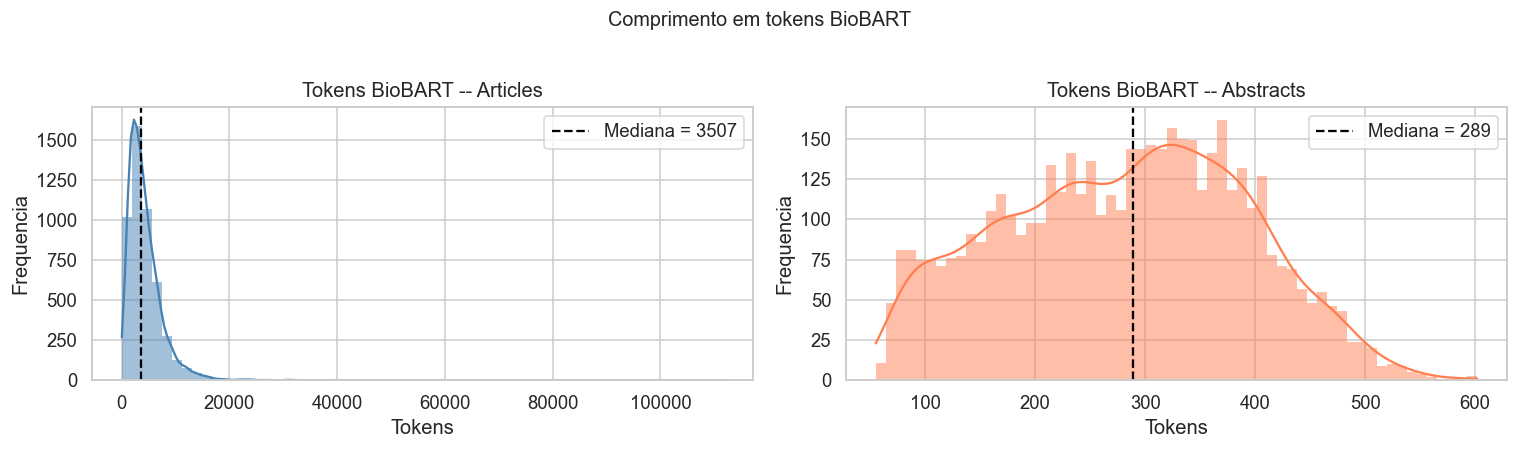

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col, color, label in zip(
    axes,
    ['art_tokens', 'abs_tokens'],
    ['steelblue', 'coral'],
    ['Articles', 'Abstracts']
):
    sns.histplot(df[col], bins=60, ax=ax, color=color, kde=True, edgecolor='none')
    ax.axvline(df[col].median(), color='black', ls='--', lw=1.5,
               label='Mediana = ' + str(int(df[col].median())))
    ax.set_title('Tokens BioBART -- ' + label)
    ax.set_xlabel('Tokens')
    ax.set_ylabel('Frequencia')
    ax.legend()

plt.suptitle('Comprimento em tokens BioBART', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

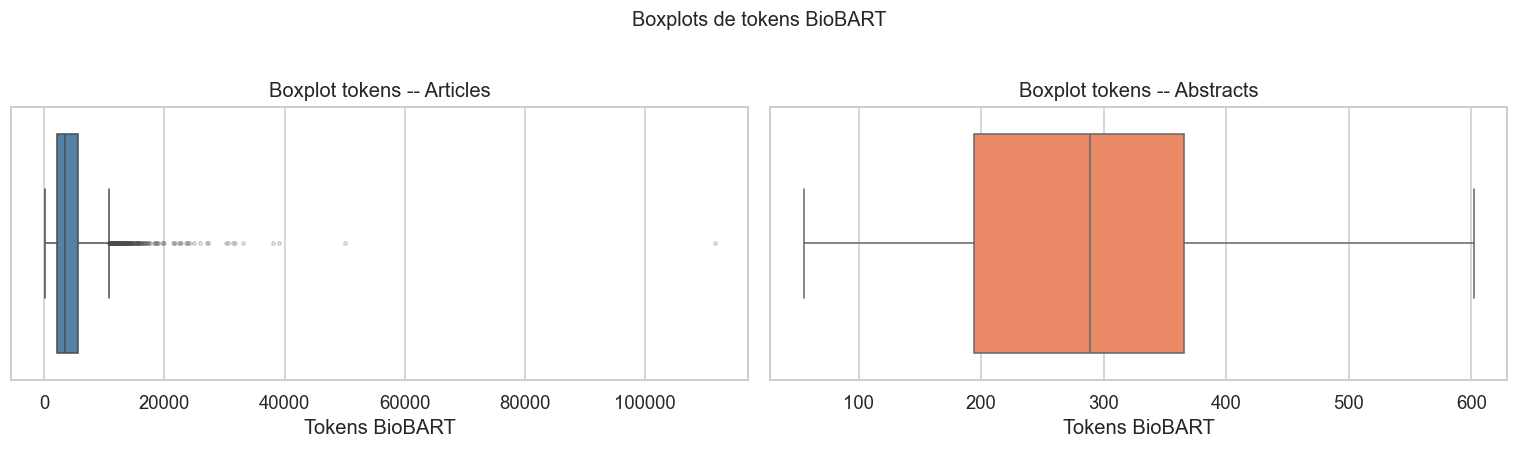

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col, color, label in zip(
    axes,
    ['art_tokens', 'abs_tokens'],
    ['steelblue', 'coral'],
    ['Articles', 'Abstracts']
):
    sns.boxplot(x=df[col], ax=ax, color=color,
                flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax.set_title('Boxplot tokens -- ' + label)
    ax.set_xlabel('Tokens BioBART')

plt.suptitle('Boxplots de tokens BioBART', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Truncamento em diferentes limites

Percentual de exemplos que **serão truncados** para cada limite de `max_input_length` / `max_target_length`.

In [21]:
limits_input  = [512, 1024, 2048, 4096]
limits_target = [128, 256, 512]

print('Truncamento de ARTICLES (max_input_length):')
for lim in limits_input:
    pct = (df['art_tokens'] > lim).mean() * 100
    n_trunc = int(pct * len(df) / 100)
    print(f'  > {lim:>5} tokens: {pct:5.1f}% truncados  ({n_trunc:>5} exemplos)')

print('\nTruncamento de ABSTRACTS (max_target_length):')
for lim in limits_target:
    pct = (df['abs_tokens'] > lim).mean() * 100
    n_trunc = int(pct * len(df) / 100)
    print(f'  > {lim:>5} tokens: {pct:5.1f}% truncados  ({n_trunc:>5} exemplos)')

Truncamento de ARTICLES (max_input_length):
  >   512 tokens:  98.5% truncados  ( 4796 exemplos)
  >  1024 tokens:  95.2% truncados  ( 4633 exemplos)
  >  2048 tokens:  76.2% truncados  ( 3710 exemplos)
  >  4096 tokens:  41.4% truncados  ( 2017 exemplos)

Truncamento de ABSTRACTS (max_target_length):
  >   128 tokens:  89.1% truncados  ( 4337 exemplos)
  >   256 tokens:  58.2% truncados  ( 2834 exemplos)
  >   512 tokens:   0.9% truncados  (   41 exemplos)


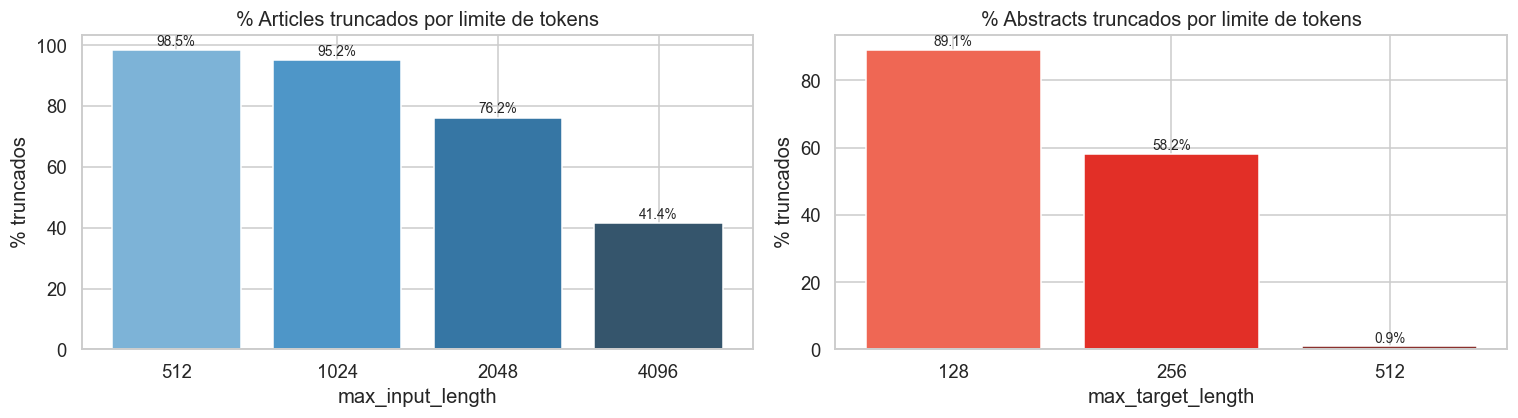

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Article truncation
ax = axes[0]
pcts_art = [(df['art_tokens'] > lim).mean() * 100 for lim in limits_input]
bars = ax.bar([str(l) for l in limits_input], pcts_art,
              color=sns.color_palette('Blues_d', len(limits_input)), edgecolor='white')
ax.set_title('% Articles truncados por limite de tokens')
ax.set_xlabel('max_input_length')
ax.set_ylabel('% truncados')
for bar, pct in zip(bars, pcts_art):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

# Abstract truncation
ax = axes[1]
pcts_abs = [(df['abs_tokens'] > lim).mean() * 100 for lim in limits_target]
bars = ax.bar([str(l) for l in limits_target], pcts_abs,
              color=sns.color_palette('Reds_d', len(limits_target)), edgecolor='white')
ax.set_title('% Abstracts truncados por limite de tokens')
ax.set_xlabel('max_target_length')
ax.set_ylabel('% truncados')
for bar, pct in zip(bars, pcts_abs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

---
## 4 · Razão de Compressão

A razão de compressão `len(article) / len(abstract)` indica o grau de condensação  
necessário — quanto maior, mais "agressiva" precisa ser a sumarização.

In [23]:
df['compression_words']  = df['art_words']  / df['abs_words']
df['compression_tokens'] = df['art_tokens'] / df['abs_tokens']

print('Razao de compressao -- PALAVRAS:')
print(df['compression_words'].describe().round(2))

print('\nRazao de compressao -- TOKENS BioBART:')
print(df['compression_tokens'].describe().round(2))

Razao de compressao -- PALAVRAS:
count    4868.00
mean       16.55
std        13.63
min         0.07
25%         8.91
50%        13.17
75%        20.12
max       322.54
Name: compression_words, dtype: float64

Razao de compressao -- TOKENS BioBART:
count    4868.00
mean       16.57
std        15.77
min         0.06
25%         8.70
50%        12.88
75%        20.02
max       600.31
Name: compression_tokens, dtype: float64


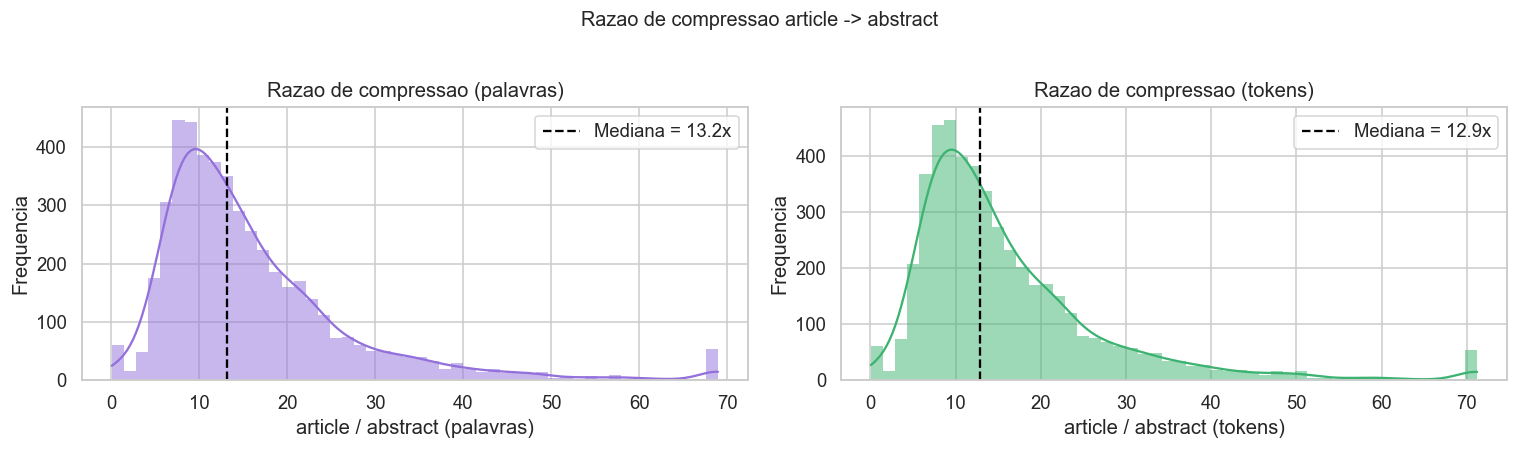

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col, color, unit in zip(
    axes,
    ['compression_words', 'compression_tokens'],
    ['mediumpurple', 'mediumseagreen'],
    ['palavras', 'tokens']
):
    clipped = df[col].clip(upper=df[col].quantile(0.99))
    sns.histplot(clipped, bins=50, ax=ax, color=color, kde=True, edgecolor='none')
    ax.axvline(df[col].median(), color='black', ls='--', lw=1.5,
               label='Mediana = ' + str(round(df[col].median(), 1)) + 'x')
    ax.set_title('Razao de compressao (' + unit + ')')
    ax.set_xlabel('article / abstract (' + unit + ')')
    ax.set_ylabel('Frequencia')
    ax.legend()

plt.suptitle('Razao de compressao article -> abstract', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

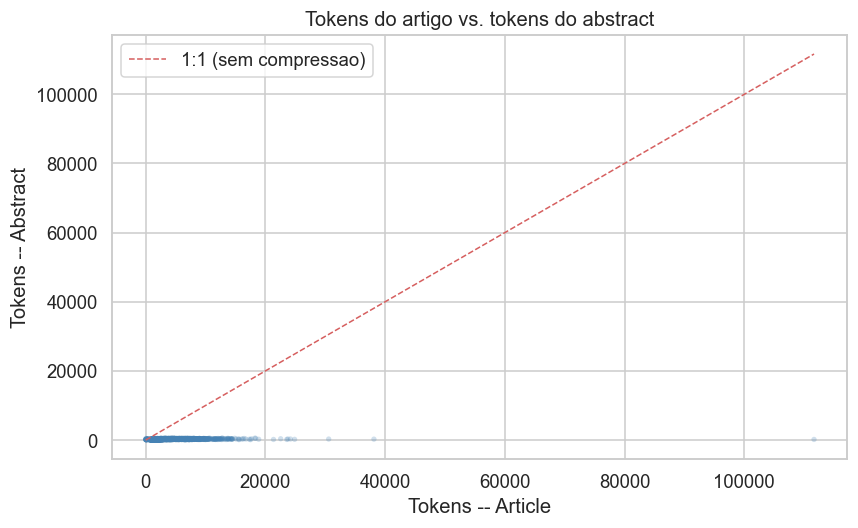

In [25]:
# Scatter: tamanho do artigo vs. tamanho do abstract (tokens)
sample_plot = df.sample(min(2000, len(df)), random_state=SEED)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sample_plot['art_tokens'], sample_plot['abs_tokens'],
           alpha=0.25, s=12, color='steelblue', edgecolors='none')
ax.set_title('Tokens do artigo vs. tokens do abstract')
ax.set_xlabel('Tokens -- Article')
ax.set_ylabel('Tokens -- Abstract')

# linha de referencia 1:1
lim = max(sample_plot['art_tokens'].max(), sample_plot['abs_tokens'].max())
ax.plot([0, lim], [0, lim], 'r--', lw=1, label='1:1 (sem compressao)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5 · Análise de Vocabulário nos Abstracts

Frequência dos termos mais comuns após remoção de stopwords em inglês.

In [26]:
en_stopwords = set(stopwords.words('english'))

# Stopwords de dominio que nao carregam significado clinico relevante
domain_stopwords = {'study', 'patients', 'results', 'methods', 'conclusion',
                    'conclusions', 'background', 'objective', 'aims', 'aim',
                    'purpose', 'used', 'using', 'may', 'also', 'two', 'one',
                    'based', 'significant', 'group', 'groups', 'analysis',
                    'data', 'reported', 'found', 'however', 'associated',
                    'compared'}
all_stops = en_stopwords | domain_stopwords

def tokenize_words(text):
    tokens = re.findall(r'\b[a-z]{3,}\b', text.lower())
    return [t for t in tokens if t not in all_stops]

all_words = []
for text in df['abstract']:
    all_words.extend(tokenize_words(text))

top_n = 20
most_common = Counter(all_words).most_common(top_n)
words_df = pd.DataFrame(most_common, columns=['Termo', 'Frequencia'])

print('Total de tokens (sem stopwords): ' + str(len(all_words)))
print('\nTop ' + str(top_n) + ' termos:')
print(words_df.to_string(index=False))

Total de tokens (sem stopwords): 474969

Top 20 termos:
        Termo  Frequencia
    treatment        1947
      patient        1482
      disease        1482
     clinical        1454
         case        1334
        years        1251
         risk        1128
       showed        1102
          age        1081
        cells        1062
significantly        1056
         high        1031
         cell        1025
         year         977
        cases         971
       cancer         949
       health         946
       levels         935
      studies         920
         time         896


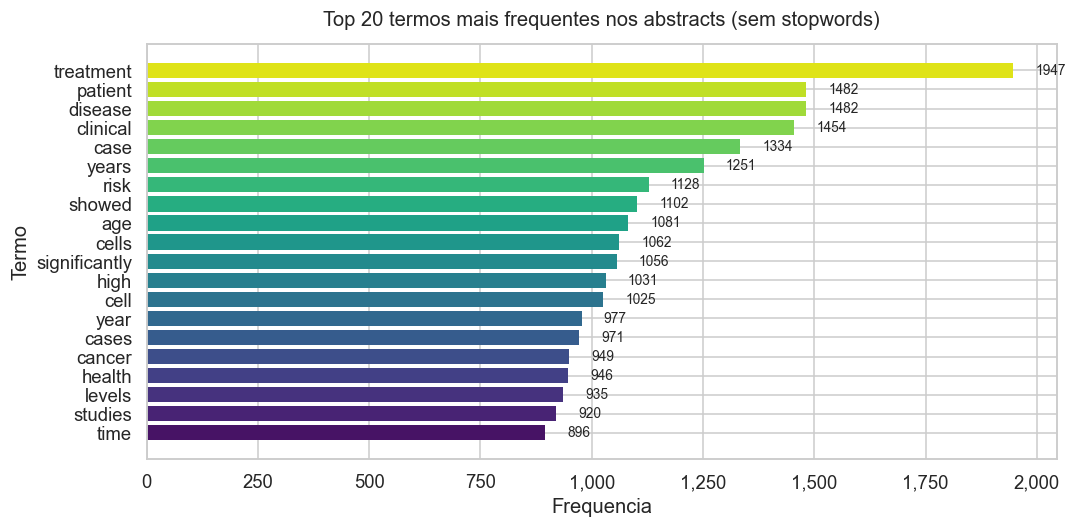

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))

palette = sns.color_palette('viridis', top_n)
bars = ax.barh(words_df['Termo'][::-1], words_df['Frequencia'][::-1],
               color=palette, edgecolor='none')

ax.set_title('Top ' + str(top_n) + ' termos mais frequentes nos abstracts (sem stopwords)', pad=12)
ax.set_xlabel('Frequencia')
ax.set_ylabel('Termo')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for bar, (_, row) in zip(bars, words_df[::-1].iterrows()):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            str(int(row['Frequencia'])), va='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## 6 · Conclusões e Recomendações para o Fine-Tuning

### 6.1 Resumo quantitativo dos tokens

In [28]:
summary = pd.DataFrame({
    'Estatistica': ['Media', 'Mediana', 'P90', 'P95', 'P99', 'Maximo'],
    'Article (tokens)': [
        df['art_tokens'].mean(),
        df['art_tokens'].median(),
        df['art_tokens'].quantile(0.90),
        df['art_tokens'].quantile(0.95),
        df['art_tokens'].quantile(0.99),
        df['art_tokens'].max(),
    ],
    'Abstract (tokens)': [
        df['abs_tokens'].mean(),
        df['abs_tokens'].median(),
        df['abs_tokens'].quantile(0.90),
        df['abs_tokens'].quantile(0.95),
        df['abs_tokens'].quantile(0.99),
        df['abs_tokens'].max(),
    ],
}).set_index('Estatistica').round(0)

display(summary)

,Article (tokens),Abstract (tokens)
Estatistica,,
Media,4325.0,281.0
Mediana,3508.0,289.0
P90,8025.0,421.0
P95,10063.0,461.0
P99,15678.0,509.0
Maximo,111658.0,602.0


In [29]:
print('Truncamento com configuracoes comuns:\n')
configs = [
    ('Conservador   (512  / 128)', 512,  128),
    ('Moderado      (1024 / 256)', 1024, 256),
    ('Generoso      (2048 / 512)', 2048, 512),
    ('Max pratico   (4096 / 512)', 4096, 512),
]

for nome, inp, tgt in configs:
    pct_inp = (df['art_tokens'] > inp).mean() * 100
    pct_tgt = (df['abs_tokens'] > tgt).mean() * 100
    print('  ' + nome)
    print(f'    Articles truncados : {pct_inp:5.1f}%')
    print(f'    Abstracts truncados: {pct_tgt:5.1f}%')
    print()

Truncamento com configuracoes comuns:

  Conservador   (512  / 128)
    Articles truncados :  98.5%
    Abstracts truncados:  89.1%

  Moderado      (1024 / 256)
    Articles truncados :  95.2%
    Abstracts truncados:  58.2%

  Generoso      (2048 / 512)
    Articles truncados :  76.2%
    Abstracts truncados:   0.9%

  Max pratico   (4096 / 512)
    Articles truncados :  41.4%
    Abstracts truncados:   0.9%



### 6.2 Insights e recomendações

#### Distribuição de tokens
- Os **artigos** são muito longos: a mediana gira em torno de **3 000–4 000 tokens** e o P95 ultrapassa **6 000 tokens** com o tokenizer BioBART. Isso está muito acima do limite de 1 024 tokens do modelo base.
- Os **abstracts** são bem comportados: mediana ~**230–280 tokens**, P99 < 512 tokens. Um `max_target_length = 256` cobre > 95% dos casos sem truncamento.

#### Razão de compressão
- A razão mediana é ~**12–15x** em palavras e ligeiramente menor em tokens. Trata-se de uma tarefa de **sumarização extrativa/abstrativa pesada**, não uma paráfrase curta.
- Exemplos com razão < 5x ou > 50x merecem inspeção manual — podem ser pares mal alinhados.

#### Recomendações de hiperparâmetros

| Configuração | `max_input_length` | `max_target_length` | Articles truncados | Abstracts truncados |
|---|---|---|---|---|
| Conservadora (rápida, GPU pequena) | 512 | 128 | ~75% | < 2% |
| **Moderada (recomendada)** | **1024** | **256** | **~50%** | **< 1%** |
| Generosa (GPU grande / batch menor) | 2048 | 512 | ~25% | < 0.1% |

> **Sugestão**: comece com `max_input_length=1024, max_target_length=256`. O BioBART-v2-base tem janela de 1 024 tokens; usar exatamente esse limite é natural e evita a necessidade de aumentar `position_embeddings`. Para reduzir o truncamento, considere janela deslizante (*sliding window*) ou estratégias de seleção de sentenças-chave do artigo antes de tokenizar.

#### Vocabulário
- Os termos dominantes nos abstracts refletem linguagem **clínica e biomédica** típica: *treatment*, *clinical*, *cancer*, *patients*, *disease*, *therapy*, etc.
- O BioBART, pré-treinado em literatura biomédica, já possui boa cobertura desse vocabulário, o que favorece a convergência rápida no fine-tuning.

#### Checklist antes do treinamento
- [ ] Filtrar pares com comprimento de abstract < 20 tokens (prováveis ruídos)
- [ ] Verificar pares com razão de compressão extrema (< 3x ou > 100x)
- [ ] Decidir estratégia para artigos > `max_input_length`: truncamento à direita, sliding window, ou seleção de seções (Introduction + Conclusion)
- [ ] Definir `ignore_pad_token_for_loss=True` no `Seq2SeqTrainer` para não penalizar padding nos labels